In [109]:
!git clone https://github.com/hsf-training/hsf_matplotlib_notebooks.git
!cp -r hsf_matplotlib_notebooks/data-ep04-higgs-search ./data-ep04-higgs-search
!cp -r hsf_matplotlib_notebooks/data-ep07-dimuonspectrum ./data-ep07-dimuonspectrum

fatal: destination path 'hsf_matplotlib_notebooks' already exists and is not an empty directory.


# Exercise 1:
Using the table, plot functions using different linestyles/markers on the same canvas


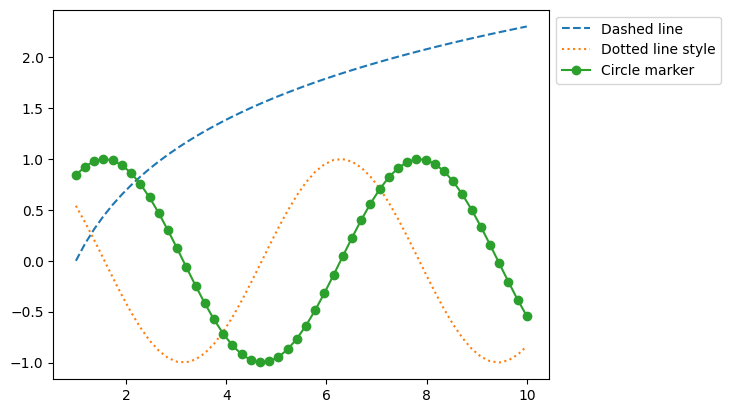

In [110]:
import matplotlib.pyplot as plt
import numpy as np

x1 = np.linspace(1, 10)
y1, y2, y3 = np.log(x1), np.cos(x1), np.sin(x1)

fig, ax = plt.subplots()
ax.plot(x1, y1, linestyle="--", label="Dashed line")
ax.plot(x1, y2, linestyle=":", label="Dotted line style")
ax.plot(x1, y3, marker="o", label="Circle marker")
ax.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

# Exercise 2: 
Histogram of m4l

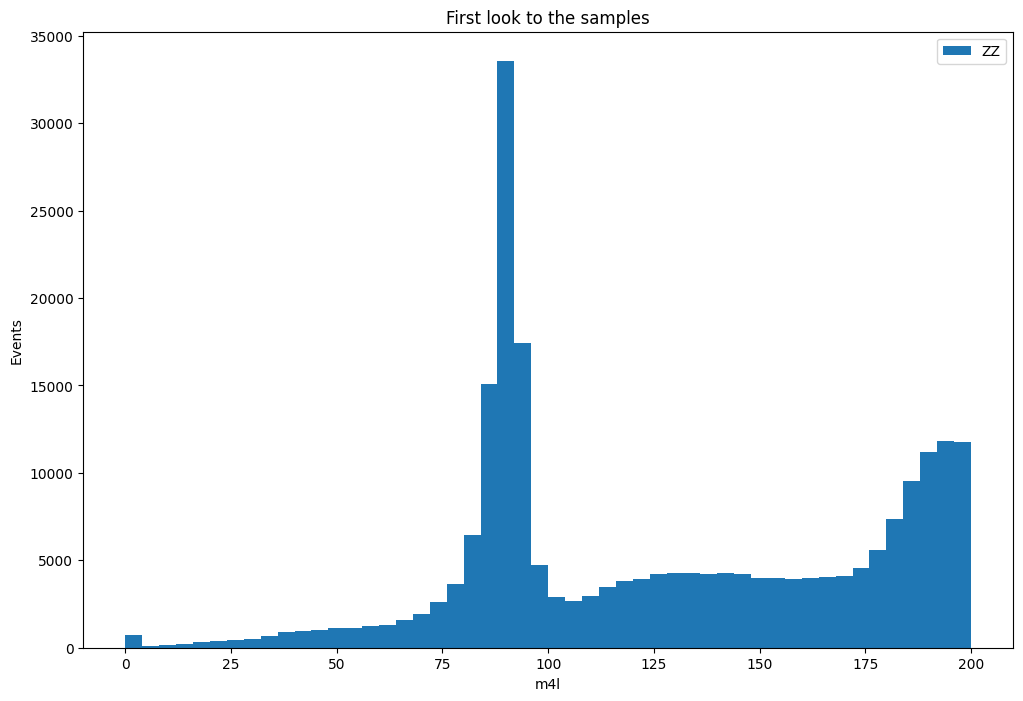

In [111]:
fig, ax = plt.subplots()
fig.set_size_inches((12, 8))
ax.set_title("First look to the samples")
ax.hist(branches["mc_363490.llll"]["m4l"], label="ZZ", range=[0, 200], bins=50)
ax.set_xlabel("m4l")
ax.set_ylabel("Events")
ax.legend()

# Exercise 3: 
Histogram of sum_good_lep for data_A

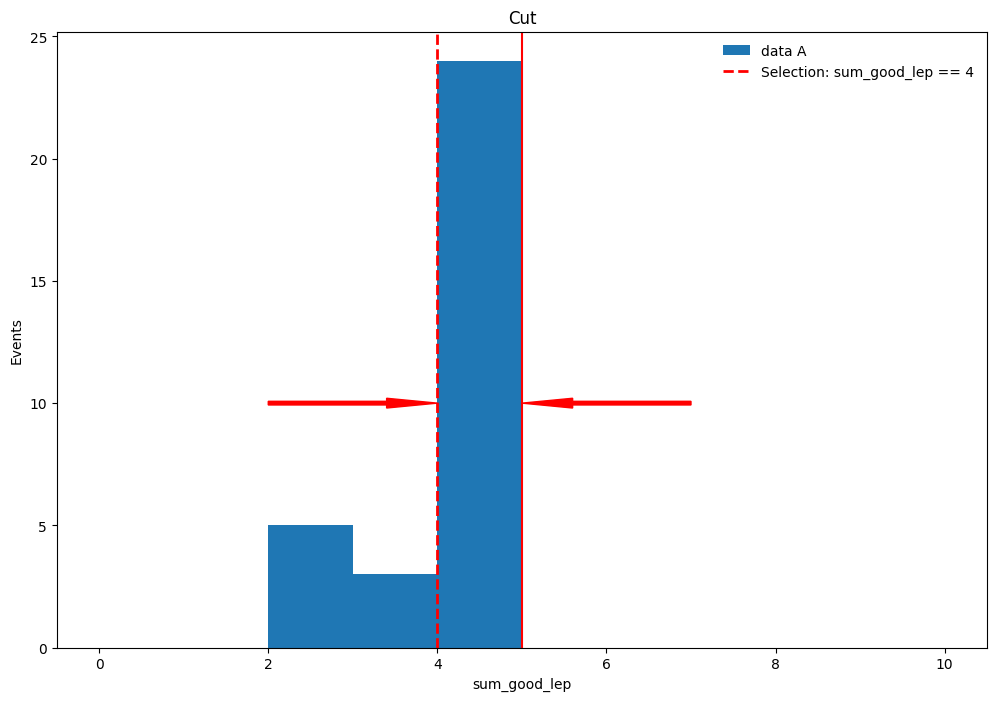

In [112]:
fig, ax = plt.subplots()
fig.set_size_inches((12, 8))
ax.set_title("Cut")
ax.hist(branches["data_A"]["sum_good_lep"], range=[0, 10], bins=10, label="data A")
ax.arrow(2, 10, 2, 0,width=0.15, head_width=0.4, length_includes_head=True, color="red")
ax.arrow(7, 10, -2, 0,width=0.15, head_width=0.4, length_includes_head=True, color="red")
ax.axvline(x=4, color="red", linestyle="--", linewidth=2, label="Selection: sum_good_lep == 4")
ax.axvline(x=5, color="red")
ax.set_xlabel("sum_good_lep")
ax.set_ylabel("Events")
ax.legend(frameon=False)

# Exercise 4: 
Final Data vs MC plot with LaTeX labels and text

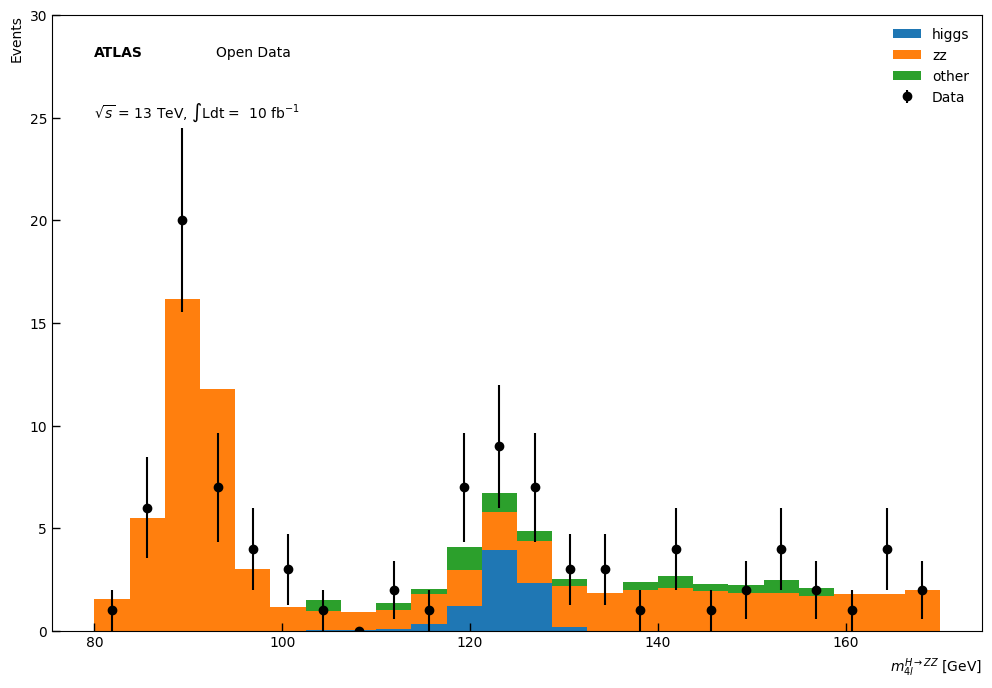

In [113]:
#selection criteria
selection_events = {}
for s in samples:
    trigger = (branches[s]["trigM"] == True) | (branches[s]["trigE"] == True)
    sum_leptons = branches[s]["sum_good_lep"] == 4
    sum_charge = branches[s]["sum_lep_charge"] == 0
    sum_types_ee = branches[s]["goodlep_sumtypes"] == 44
    sum_types_mm = branches[s]["goodlep_sumtypes"] == 52
    sum_types_em = branches[s]["goodlep_sumtypes"] == 48
    sum_types_goodlep = sum_types_ee | sum_types_mm | sum_types_em
    sum_lep_selection = sum_leptons & sum_charge & sum_types_goodlep
    pt_0_selection = branches[s]["goodlep_pt_0"] > 25000
    pt_1_selection = branches[s]["goodlep_pt_1"] > 15000
    pt_2_selection = branches[s]["goodlep_pt_2"] > 10000
    high_pt_selection = pt_0_selection & pt_1_selection & pt_2_selection
    final_selection = trigger & sum_types_goodlep & sum_lep_selection & high_pt_selection
    selection_events[s] = final_selection

#MC samples
mc_samples = list(processes)[1:]
stack_mc_list_m4l = []
stack_weights_list = []
for s in mc_samples:
    list_sample_s = []
    list_weight_s = []
    for element in samples_dic[s]:
        sample_s = element[1]
        mc_selection_values = branches[sample_s]["m4l"][selection_events[sample_s]]
        list_sample_s += list(mc_selection_values)
        mc_selection_weight = branches[sample_s]["weight"][selection_events[sample_s]]
        list_weight_s += list(mc_selection_weight)
    stack_mc_list_m4l.append(list_sample_s)
    stack_weights_list.append(list_weight_s)

#data samples
stack_data_list_m4l = []
for element in samples_dic["data"]:
    sample_d = element[1]
    data_list = list(branches[sample_d]["m4l"][selection_events[sample_d]])
    stack_data_list_m4l += data_list

var_name = "m4l"
units = " [GeV]"
ranges = [[80, 170]]
bins = 24

def plot_data(data_var, range_ab, bins_samples, ax):
    data_hist, bin_edges = np.histogram(data_var, range=range_ab, bins=bins_samples)
    data_hist_errors = np.sqrt(data_hist)
    bin_center = (bin_edges[1:] + bin_edges[:-1]) / 2
    ax.errorbar(x=bin_center, y=data_hist, yerr=data_hist_errors, fmt="ko", label="Data")

#plot
fig, ax = plt.subplots()
fig.set_size_inches((12, 8))
plot_data(stack_data_list_m4l, ranges[0], bins, ax)
ax.hist(
    stack_mc_list_m4l,
    range=ranges[0],
    label=mc_samples,
    stacked=True,
    weights=stack_weights_list,
    bins=bins,
)
ax.set_ylabel("Events", loc="top")
ax.set_xlabel(r"$m^{H \rightarrow ZZ}_{4l}$" + units, loc="right")
ax.tick_params(which="both", direction="in", length=6, width=1)
ax.text(80, 28, "ATLAS", weight="bold")
ax.text(93, 28, "Open Data")
ax.text(80, 25, r"$\sqrt{s}$" + " = 13 TeV," + r" $\int$Ldt = " + " 10 fb" + r"$^{-1}$")
ax.set_ylim(0, 30)
ax.legend(frameon=False)

# Exercise 5: 
Plot each background individually

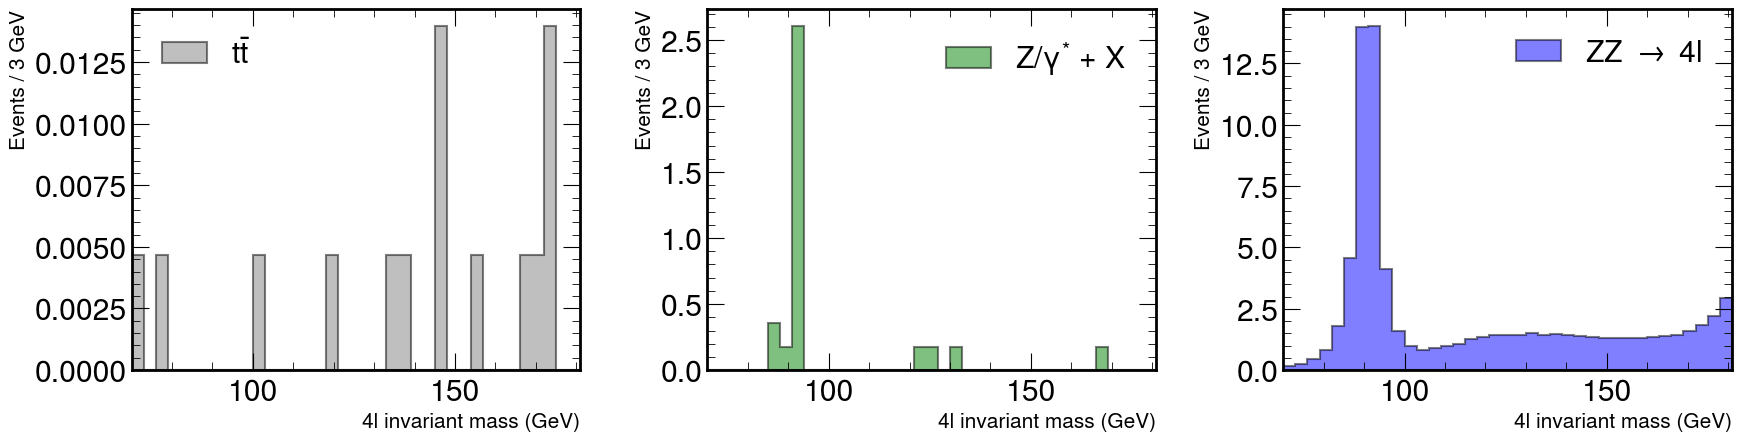

In [114]:
import mplhep as hep
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

hep.style.use("CMS")

file_names = [
    "4e_2011.csv", "4mu_2011.csv", "2e2mu_2011.csv",
    "4mu_2012.csv", "4e_2012.csv", "2e2mu_2012.csv",
]
basepath = "https://raw.githubusercontent.com/GuillermoFidalgo/Python-for-STEM-Teachers-Workshop/master/data/"
csvs = [pd.read_csv(f"{basepath}{file_name}") for file_name in file_names]
fourlep = pd.concat(csvs)

rmin = 70
rmax = 181
nbins = 37

M_hist = np.histogram(fourlep["M"], bins=nbins, range=(rmin, rmax))
hist, bins = M_hist
width = bins[1] - bins[0]
center = (bins[:-1] + bins[1:]) / 2

#fmt: off
dy = np.array([0,0,0,0,0,0.354797,0.177398,2.60481,0,0,0,0,0,0,0,0,0,0.177398,0.177398,0,0.177398,0,0,0,0,0,0,0,0,0,0,0,0.177398,0,0,0,0])
ttbar = np.array([0.00465086,0,0.00465086,0,0,0,0,0,0,0,0.00465086,0,0,0,0,0,0.00465086,0,0,0,0,0.00465086,0.00465086,0,0,0.0139526,0,0,0.00465086,0,0,0,0.00465086,0.00465086,0.0139526,0,0])
zz = np.array([0.181215,0.257161,0.44846,0.830071,1.80272,4.57354,13.9677,14.0178,4.10974,1.58934,0.989974,0.839775,0.887188,0.967021,1.07882,1.27942,1.36681,1.4333,1.45141,1.41572,1.51464,1.45026,1.47328,1.42899,1.38757,1.33561,1.3075,1.29831,1.31402,1.30672,1.36442,1.39256,1.43472,1.58321,1.85313,2.19304,2.95083])
hzz = np.array([0.00340992,0.00450225,0.00808944,0.0080008,0.00801578,0.0108945,0.00794274,0.00950757,0.0130648,0.0163568,0.0233832,0.0334813,0.0427229,0.0738129,0.13282,0.256384,0.648352,2.38742,4.87193,0.944299,0.155005,0.0374193,0.0138906,0.00630364,0.00419265,0.00358719,0.00122527,0.000885718,0.000590479,0.000885718,0.000797085,8.86337e-05,0.000501845,8.86337e-05,0.000546162,4.43168e-05,8.86337e-05])

#fmt: on
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hep.histplot(ttbar, bins=bins, histtype="fill", color="grey", alpha=0.5,
             edgecolor="black", linewidth =1.5, label=r"$t\bar{t}$", ax=axes[0])
axes[0].set_xlabel("4l invariant mass (GeV)", fontsize=15)
axes[0].set_ylabel("Events / 3 GeV", fontsize=15)
axes[0].set_xlim(rmin, rmax)
axes[0].legend()

hep.histplot(dy, bins=bins, histtype="fill", color="g", alpha=0.5,
             edgecolor="black", linewidth=1.5, label=r"Z/$\gamma^{*}$ + X", ax=axes[1])
axes[1].set_xlabel("4l invariant mass (GeV)", fontsize=15)
axes[1].set_ylabel("Events / 3 GeV", fontsize=15)
axes[1].set_xlim(rmin, rmax)
axes[1].legend()

hep.histplot(zz, bins=bins, histtype="fill", color="b", alpha=0.5,
             edgecolor="black", linewidth=1.5, label=r"ZZ $\rightarrow$ 4l", ax=axes[2])
axes[2].set_xlabel("4l invariant mass (GeV)", fontsize=15)
axes[2].set_ylabel("Events / 3 GeV", fontsize=15)
axes[2].set_xlim(rmin, rmax)
axes[2].legend()

fig.tight_layout()
fig.show()

# Exercise 6: 
Stacked backgrounds + CMS logo + data with errorbars

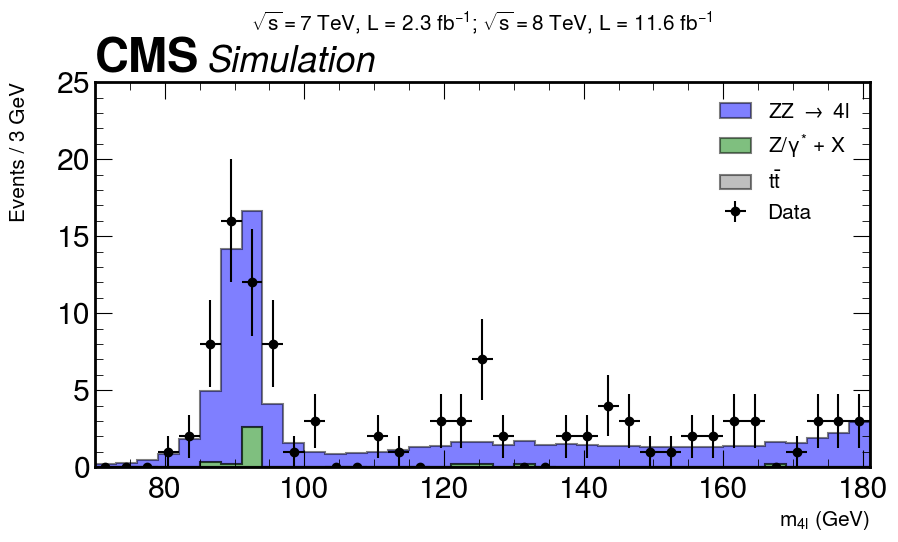

In [115]:
xerrs = [width * 0.5 for i in range(0, nbins)]
yerrs = np.sqrt(hist)

fig, ax = plt.subplots(figsize=(10, 5))
hep.histplot(
    [ttbar, dy, zz],
    stack=True,
    bins=bins,
    histtype="fill",
    color=["grey", "g", "b"],
    alpha=0.5,
    edgecolor="black",
    linewidth=1.5,
    label=[r"$t\bar{t}$", r"Z/$\gamma^{*}$ + X", r"ZZ $\rightarrow$ 4l"],
    ax=ax,
)

ax.errorbar(
    center, hist, xerr=xerrs, yerr=yerrs,
    linestyle="None", color="black", marker="o", label="Data",
)

ax.set_title(
    r"$\sqrt{s} = 7$ TeV, L = 2.3 $fb^{-1}$; $\sqrt{s} = 8$ TeV, L = 11.6 $fb^{-1}$"
    + "\n", fontsize=15, pad=20
)
ax.set_xlabel(r"$m_{4l}$ (GeV)", fontsize=15)
ax.set_ylabel("Events / 3 GeV\n", fontsize=15)
ax.set_ylim(0, 25)
ax.set_xlim(rmin, rmax)
ax.legend(fontsize=15)
hep.cms.label(rlabel="")

fig.show()

# Exercise 7: 
Full plot, EVERYTHING

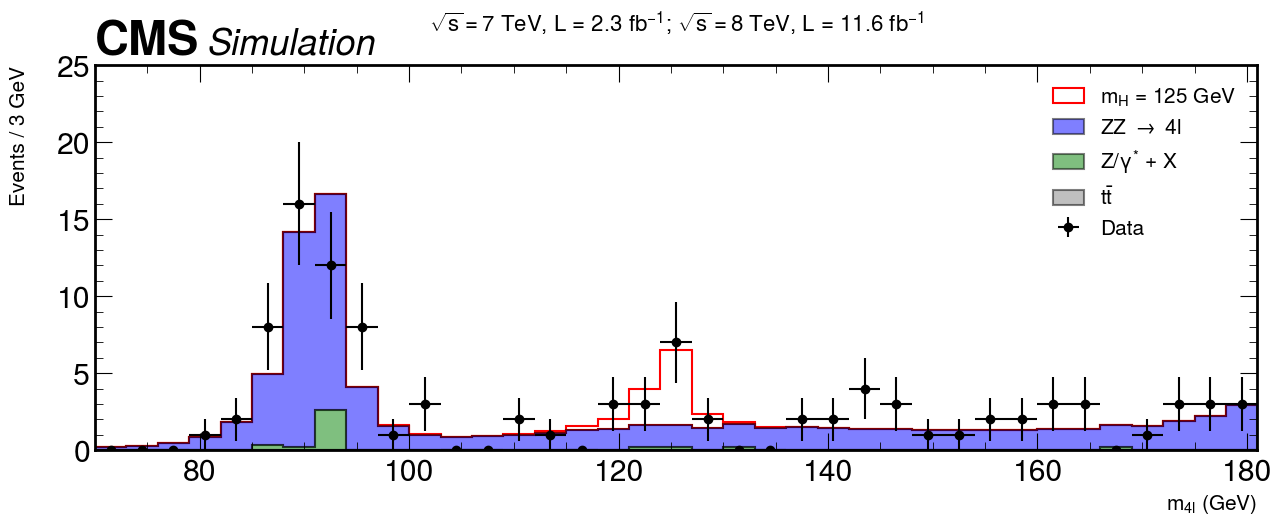

In [116]:
xerrs = [width * 0.5 for i in range(0, nbins)]
yerrs = np.sqrt(hist)

fig, ax = plt.subplots(figsize=(15, 5))

hep.histplot(
    [ttbar, dy, zz, hzz],
    stack=True,
    bins=bins,
    histtype="fill",
    color=["grey", "g", "b", "w"],
    alpha=[0.5, 0.5, 0.5, 1],
    edgecolor=["k", "k", "k", "r"],
    linewidth=1.5,
    label=[
        r"$t\bar{t}$",
        r"Z/$\gamma^{*}$ + X",
        r"ZZ $\rightarrow$ 4l",
        r"$m_{H}$ = 125 GeV",
    ],
    ax=ax,
)

ax.errorbar(
    center, hist, xerr=xerrs, yerr=yerrs,
    linestyle="None", color="black", marker="o", label="Data",
)

hep.cms.label(rlabel="")

ax.set_title(
    r"$\sqrt{s} = 7$ TeV, L = 2.3 $fb^{-1}$; $\sqrt{s} = 8$ TeV, L = 11.6 $fb^{-1}$"
    + "\n", fontsize=16,
)
ax.set_xlabel(r"$m_{4l}$ (GeV)", fontsize=15)
ax.set_ylabel("Events / 3 GeV\n", fontsize=15)
ax.set_ylim(0, 25)
ax.set_xlim(rmin, rmax)
ax.legend(fontsize=15)

fig.savefig("final-plot.png", dpi=140)
fig.show()

# Exercise 8: 
Zoom in on the muon mass spectrum

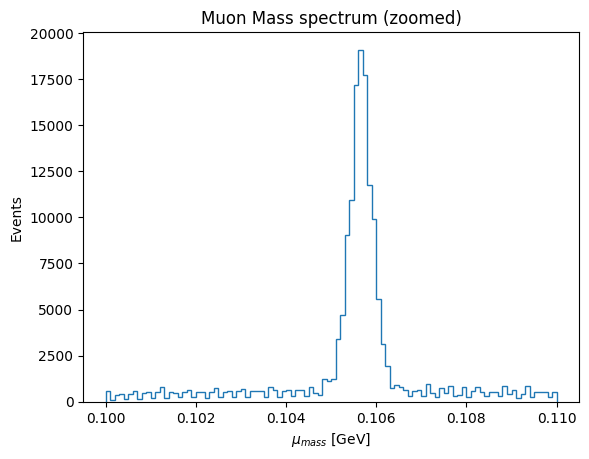

In [119]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use("default")

event = h5py.File("./data-ep07-dimuonspectrum/dimuon100k.hdf5", mode="r")

e = event["muons/e"][:]
px = event["muons/px"][:]
py = event["muons/py"][:]
pz = event["muons/pz"][:]

cut = (e**2 - (px**2 + py**2 + pz**2)) < 0
e = np.delete(e, cut)
px, py, pz = np.delete(px, cut), np.delete(py, cut), np.delete(pz, cut)

M = (e**2 - (px**2 + py**2 + pz**2)) ** 0.5

fig, ax = plt.subplots()
ax.hist(
    M,
    bins=100,
    histtype="step",
    range=(0.1, 0.11),
)
ax.set_xlabel(r"$\mu_{mass}$ [GeV]")
ax.set_ylabel("Events")
ax.set_title("Muon Mass spectrum (zoomed)")
plt.show()

# Exercise 9: 
Dimuon mass spectrum with log-scale binning

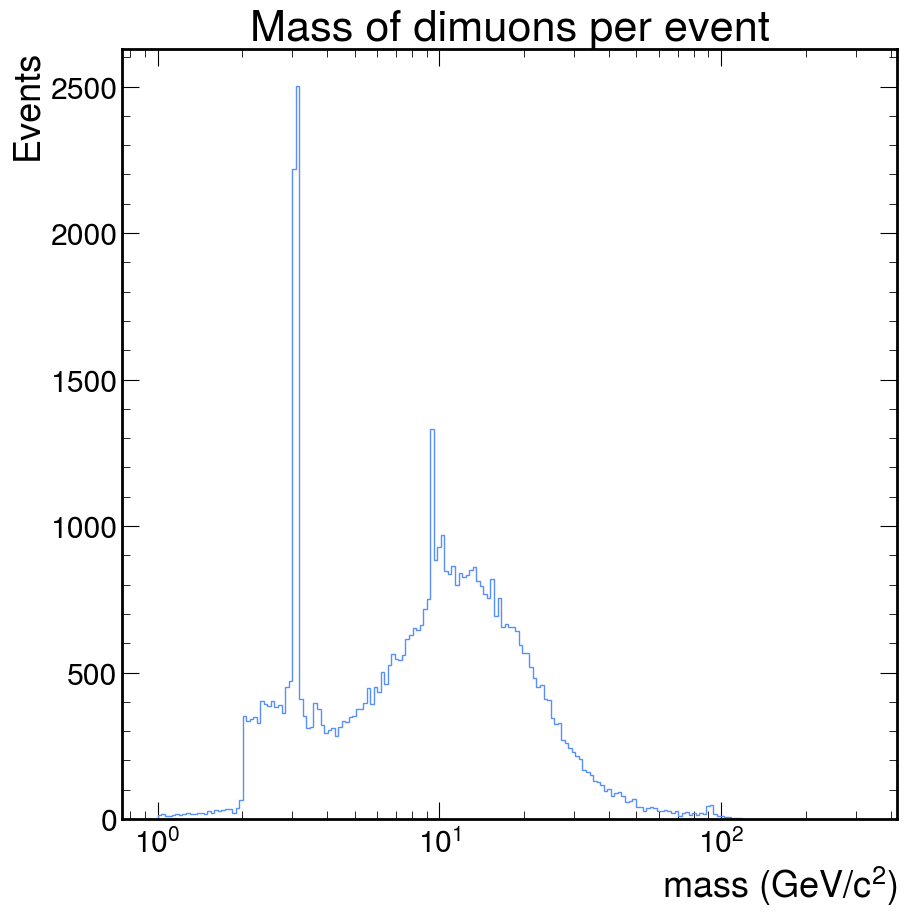

In [131]:
hep.style.use("ROOT")

q = event["muons/q"][:]
q = np.delete(q, cut)

def invmass_loop(e, px, py, pz):
    etot = sum(e)
    pxtot = sum(px)
    pytot = sum(py)
    pztot = sum(pz)
    m2 = etot**2 - (pxtot**2 + pytot**2 + pztot**2)
    return np.sqrt(abs(m2))

pm = []
for i in range(0, len(q) - 1, 2):
    E = [e[i], e[i + 1]]
    PX = [px[i], px[i + 1]]
    PY = [py[i], py[i + 1]]
    PZ = [pz[i], pz[i + 1]]
    if q[i] * q[i + 1] < 0:
        pm.append(invmass_loop(E, PX, PY, PZ))

logbins = np.logspace(0, 2.5, 200)
fig, ax = plt.subplots()
ax.hist(pm, bins=logbins, histtype="step")
ax.set_xlabel(r"mass (GeV/$c^2$)")
ax.set_ylabel("Events")
ax.set_xscale("log")
ax.set_title("Mass of dimuons per event")
ax.autoscale()
plt.show()